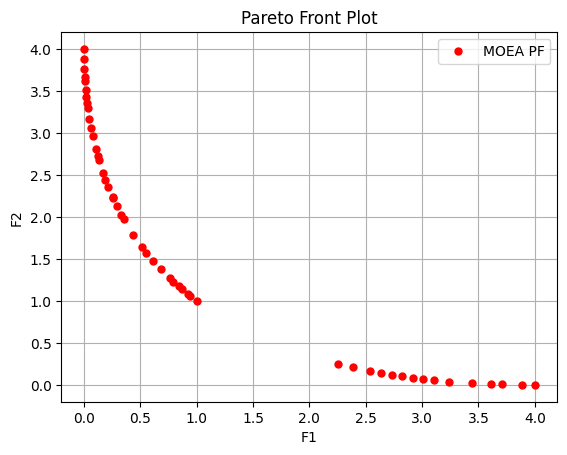

Execution time: 0.2432234287261963 s
Evaluation number: 10000
The number of non-dominated solutions is: 50
hv: 0.83010
spacing: 0.04106
{'success': True, 'stopMsg': 'The algotirhm stepped because it exceeded the generation limit.', 'optPop': <geatpy.Population.Population object at 0x7ff55b336c50>, 'lastPop': <geatpy.Population.Population object at 0x7ff55b336bc0>, 'Vars': array([[ 8.90948727e-01],
       [ 1.62352134e+00],
       [ 9.75103954e-02],
       [ 1.70864374e+00],
       [ 2.91967310e-02],
       [ 8.41092557e-02],
       [ 2.21979487e-01],
       [ 7.85855567e-01],
       [ 5.05454232e-01],
       [ 1.76290037e+00],
       [ 1.85645022e+00],
       [ 6.61916171e-01],
       [ 3.25798504e-01],
       [ 1.68067169e+00],
       [ 8.25451785e-01],
       [ 1.50112846e+00],
       [ 9.99921152e-01],
       [ 9.33118549e-01],
       [ 9.16750885e-01],
       [ 7.17039694e-01],
       [ 1.47257386e-01],
       [-2.81261938e-06],
       [ 1.59296661e+00],
       [ 1.99984690e+00],
 

In [1]:
import numpy as np
import geatpy as ea


class MyProblem(ea.Problem):  # 继承Problem父类

    def __init__(self, M=2):
        name = 'MyProblem'  # 初始化name（函数名称，可以随意设置）
        Dim = 1  # 初始化Dim（决策变量维数）
        maxormins = [1] * M  # 初始化maxormins（目标最小最大化标记列表，1：最小化该目标；-1：最大化该目标）
        varTypes = [0] * Dim  # 初始化varTypes（决策变量的类型，0：实数；1：整数）
        lb = [-10] * Dim  # 决策变量下界
        ub = [10] * Dim  # 决策变量上界
        lbin = [1] * Dim  # 决策变量下边界（0表示不包含该变量的下边界，1表示包含）
        ubin = [1] * Dim  # 决策变量上边界（0表示不包含该变量的上边界，1表示包含）
        # 调用父类构造方法完成实例化
        ea.Problem.__init__(self, name, M, maxormins, Dim, varTypes, lb, ub, lbin, ubin)
        
    def evalVars(self, Vars):  # 目标函数
        f1 = Vars**2
        f2 = (Vars - 2)**2
        #        # 利用罚函数法处理约束条件
        #        exIdx = np.where(Vars**2 - 2.5 * Vars + 1.5 < 0)[0] # 获取不满足约束条件的个体在种群中的下标
        #        f1[exIdx] = f1[exIdx] + np.max(f1) - np.min(f1)
        #        f2[exIdx] = f2[exIdx] + np.max(f2) - np.min(f2)
        # 利用可行性法则处理约束条件
        CV = -Vars**2 + 2.5 * Vars - 1.5
        ObjV = np.hstack([f1, f2])
        return ObjV, CV
    
if __name__ == '__main__':
    # 实例化问题对象
    problem = MyProblem()
    # 构建算法
    algorithm = ea.moea_NSGA2_templet(
        problem,# 种群
        # 编码为RI，种群数量为50
        ea.Population(Encoding='RI', NIND=50),
        MAXGEN=200,  # 最大进化代数
        logTras=0)  # 表示每隔多少代记录一次日志信息，0表示不记录。
    # 求解
    res = ea.optimize(algorithm,verbose=True, drawing=1, outputMsg=True, drawLog=False, saveFlag=True)
    print(res)


In [4]:
import numpy as np
import geatpy as ea # import geatpy
# from ga_more_aim import MyProblem # 导入自定义问题接口
import matplotlib.pyplot as plt
import concurrent.futures
from pyCostEstimator import Cost_Estimator

class MyProblem(ea.Problem):  # 继承Problem父类
    def __init__(self):
        name = 'BNH'  # 初始化name（函数名称，可以随意设置）
        M = 2  # 初始化M（目标维数）
        maxormins = [1, -1] # 初始化maxormins（目标最小最大化标记列表，1：最小化该目标；-1：最大化该目标）
        Dim = 2  # 初始化Dim（决策变量维数）
        varTypes = [0] * Dim  # 初始化varTypes（决策变量的类型，0：实数；1：整数）
        lb = [18e6,11e6]  
        ub = [20e6,13e6] #  上界
        lbin = [1,1] # 决策变量下边界（0表示不包含该变量的下边界，1表示包含） 
        ubin = [1,1]  # 决策变量上边界（0表示不包含该变量的上边界，1表示包含）
        ea.Problem.__init__(self, name, M, maxormins, Dim, varTypes, lb, ub, lbin, ubin)
        Caes_parameters=self._compose_caes_parameters()
        self._Hydrator = Cost_Estimator(Caes_parameters)

        self._hot_util=10
        self._max_map_executor=4
    
    def _compose_caes_parameters(self):
        parameters = dict()
        flue_gas_composistion = dict()
        flue_gas_composistion["co2"] = 0.1338
        flue_gas_composistion["o2"] = 0.0384
        flue_gas_composistion["n2"] = 0.6975
        parameters["flue_gas_composition"] = flue_gas_composistion
        parameters["isentropic_eff_mc"] = 0.88
        parameters["t_isentropic_eff_mc"] = 0.92
        parameters["mechanical_eff"] = 0.98   #机械效率
        parameters["min_temperature_exchange"] = 15 
        parameters["deltaTmin_SSHX"] = parameters["min_temperature_exchange"]+5   #固-固换热器最小温差
        parameters["deltaTmin_SGHX"] = parameters["min_temperature_exchange"]   #固-气换热器最小温差
        parameters["industrial_waste_heat_t"] =300 #℃
        parameters["heat_transfer_loss_eff"] = 0.96
        parameters["t_amb"] = 20   #环境温度
        parameters["p_amb"] = 101325   #环境压力

        parameters["p_bray_L"] = 7.5e6
        parameters["Store_electrical_power"] = 50e6  # 机组容量
        parameters["p_water_supply_in"] = 2e5 
        parameters["water_pressure_drop_rate"] = 100 #100Pa/m
        parameters["water_pipe_length"] = 1000
        parameters["water_pump_hydraulic_efficiency"] = 0.75
        parameters["water_pump_mechanical_efficiency"] = 0.94

        parameters["cao_conversion"] = 0.95  #氧化钙转化率
        parameters["cao_purity"] = 0.98 #氢氧化钙含量
        parameters["dehydrator_eff"] = 0.95   #脱水器效率
        parameters["steam_pressure_loss_ratio"] = 0.01
        parameters["convey_consumption"] = 10e3/100
        parameters["storage_dehydrator_distance"] = 100

        parameters["hydrator_eff"] = 0.95   #水合器器效率
        parameters["p_bray_L_B"] = 7.5e6
        return parameters

    def aimFunc(self, pop):  # 目标函数
        Vars = pop.Phen  # 得到决策变量矩阵
        inputs={}
        inputs["p_bray_H"] = Vars[:, [0]]#优化变量1，热泵循环最高压力
        inputs["p_bray_M"] = Vars[:, [1]] #优化变量2，热泵循环中间压力
        inputs["p_Dehy"] = 1e5 #变量4，反应器压力
        inputs["Dehy_caoh2_in"]=444.58 #入口温度
        inputs["Dehy_overheating_temperature"] = 20 #变量2，脱水反应器过热温度

        inputs["p_bray_H_B"] = 30e6
        inputs["p_bray_MH_B"] = 16217752.142109105
        inputs["p_bray_ML_B"] = 12217752.142109105
        inputs["p_Hydr"] = 1e5
        inputs["Hydr_overheating_temperature"] = 40

        inputs["Hydr_cao_in"]=440

        inputs["cn_m1"] = 12.34*50
        inputs["m2"] = 1.532*50#补充烟气
        inputs["T_X"] = 1
        inputs["m1"] = 0#供暖水

        economic_inputs={}
        economic_inputs["elec_price"]=0.3 #元/千瓦时  ##S6
        economic_inputs["hot_price_h"] = 0.1542 #每千瓦时0.1542元，42.84元/吉焦
        economic_inputs["elec_price_h"] = 1.2784
        economic_inputs["operation_hours"]=2560 # hours  ### S9
        economic_inputs["discount_ratio"]=6/100 #8%
        economic_inputs["operational_years"]=60
        economic_inputs["operation_labour_cost_indictor"]=0.025/2*(2/3)/2 #劳动力比例
        #年运行时间为一般机组的一半,天运行时间为一般机组的2/3，投资成本为一般机组的两倍以上
        economic_inputs["maintain_cost_indictor"]=0.025/2/2 #维护比例 0.025,
        #年运行时间为一般机组的一半，投资成本为一般机组的两倍以上故修正
        results=self._Hydrator.solve(inputs,economic_inputs)
        f1 = results["LCOE"]
        f2 = results["Round-trip"]
        c0 = results["BH"]["primary_compressor"]["t_compressor_out"]-610
        c1 = results["BH"]["secondary_compressor"]["t_compressor_out"]-610
        c2 = results["Dehy"]["hot_utility"]-self._hot_util
        c3 = results["Hydr"]["HEN"]["hot_utility"]-self._hot_util
        
        constraints=[]
        constraints.append([c0,c1,c2,c3])
        # 采用可行性法则处理约束
        pop.CV=constraints
        # 把求得的目标函数值赋值给种群pop的ObjV
        pop.ObjV = np.hstack([f1, f2])

    ## 目标函数主要需要计算出CV和ObjV



"""=======================实例化问题对象==========================="""
problem = MyProblem() # 实例化问题对象
"""=========================种群设置=============================="""
Encoding = 'RI' # 编码方式
NIND = 100 # 种群规模
Field = ea.crtfld(Encoding, problem.varTypes, problem.ranges,problem.borders) # 创建区域描述器
population = ea.Population(Encoding, Field, NIND) # 实例化种群对象（此时种群还没被真正初始化，仅仅是生成一个种群对象）
"""=========================算法参数设置============================"""
myAlgorithm = ea.moea_NSGA2_templet(problem, population) # 实例化一个算法模板对象
myAlgorithm.mutOper.Pm = 0.2 # 修改变异算子的变异概率
myAlgorithm.recOper.XOVR = 0.9 # 修改交叉算子的交叉概率
myAlgorithm.MAXGEN = 200 # 最大进化代数
myAlgorithm.logTras = 1 # 设置每多少代记录日志，若设置成0则表示不记录日志
myAlgorithm.verbose = False # 设置是否打印输出日志信息
myAlgorithm.drawing = 1 # 设置绘图方式（0：不绘图；1：绘制结果图；2：绘制目标空间过程动画；3：绘制决策空间过程动画）
"""==========================调用算法模板进行种群进化==============
调用run执行算法模板，得到帕累托最优解集NDSet以及最后一代种群。
NDSet是一个种群类Population的对象。
NDSet.ObjV为最优解个体的目标函数值；NDSet.Phen为对应的决策变量值。
详见Population.py中关于种群类的定义。
"""
[NDSet, population] = myAlgorithm.run() # 执行算法模板，得到非支配种群以及最后一代种群
NDSet.save() # 把非支配种群的信息保存到文件中
"""===========================输出结果========================"""
print('用时：%s 秒' % myAlgorithm.passTime)
print('非支配个体数：%d 个' % NDSet.sizes) if NDSet.sizes != 0 else print('没有找到可行解！')
if myAlgorithm.log is not None and NDSet.sizes != 0:
    print('GD', myAlgorithm.log['gd'][-1])
    print('IGD', myAlgorithm.log['igd'][-1])
    print('HV', myAlgorithm.log['hv'][-1])
    print('Spacing', myAlgorithm.log['spacing'][-1])
"""======================进化过程指标追踪分析=================="""
metricName = [['igd'], ['hv']]
Metrics = np.array([myAlgorithm.log[metricName[i][0]] for i in range(len(metricName))]).T
# 绘制指标追踪分析图
ea.trcplot(Metrics, labels=metricName, titles=metricName)


TypeError: only length-1 arrays can be converted to Python scalars